This second part is doing PCA 

### Why PCA?

The 17 regime features are economically meaningful but **correlated and partly
redundant** — for example, the Brent, WTI and Dubai calendar spreads all move
together when the physical market tightens. Feeding them directly into K-means
would bias the clustering: groups of correlated features would collectively
dominate the Euclidean distance and implicitly over-weight the same underlying
signal (e.g. "curve shape" would count many times). PCA solves this by projecting
the 17 features onto **5 orthogonal (uncorrelated) components** that capture 81% of
the total variance. This achieves three things at once: it **removes redundancy**
(correlated features are merged into a single factor), it **denoises** the input
(the 12 trailing components, mostly noise, are dropped), and it produces a compact,
**interpretable** set of market dimensions (global curve tightness, volatility/risk-off,
East-West arbitrage, macro momentum, trans-Atlantic spread). These 5 components are
the input to the K-means step, where days with similar coordinates are grouped into
market regimes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

# Plots
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)
print("Setup OK")


Setup OK


In [3]:

# Cell 2 — Load master dataset
df = pd.read_pickle("../data/master_dataset.pkl")
print(f"Shape : {df.shape}")
print(f"Range : {df.index.min().date()} → {df.index.max().date()}")
df.head(10)

Shape : (3055, 43)
Range : 2014-01-02 → 2026-05-06


,brent_dated,brent_l1,brent_l2,brent_l3,brent_l4,brent_l5,brent_l6,wti_l1,wti_l2,wti_l3,wti_l4,wti_l5,wti_l6,cl_f_close,dubai_l1,dubai_l2,dubai_l3,gasoil_l1_usd_tonne,gasoil_l2_usd_tonne,vix,dxy,crude_stocks_us,dist_stocks_us,DFL,brent_l1_l2,brent_l1_l3,brent_l1_l6,wti_l1_l2,wti_l1_l3,wti_l1_l6,dubai_l1_l2,dubai_l1_l3,brent_wti_arb,brent_dubai_efs,gasoil_brent_crack,brent_l1_log_ret_1d,dfl_chg_1d,brent_l1_vol_20d,dfl_vol_20d,vix_chg_5d,dxy_chg_5d,crude_stock_anomaly,dist_stock_anomaly
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,108.020,107.780,107.600,107.400,107.130,106.820,106.440,95.440,95.620,95.550,95.200,94.630,93.950,95.440,107.800,107.560,107.300,934.500,935.000,14.230,93.819,NaN,NaN,0.240,0.180,0.380,1.340,-0.180,-0.110,1.490,0.240,0.500,12.340,-0.020,17.656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-03,106.605,106.890,106.540,106.240,105.900,105.560,105.180,93.960,94.140,94.060,93.750,93.240,92.610,93.960,105.240,104.930,104.680,923.750,924.250,13.760,93.853,NaN,NaN,-0.285,0.350,0.650,1.710,-0.180,-0.100,1.350,0.310,0.560,12.930,1.650,17.103,-0.008,-0.525,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-06,106.570,106.730,106.420,106.170,105.910,105.640,105.320,93.430,93.580,93.520,93.290,92.840,92.260,93.430,104.260,103.980,103.730,922.750,923.500,13.550,93.911,NaN,NaN,-0.160,0.310,0.560,1.410,-0.150,-0.090,1.170,0.280,0.530,13.300,2.470,17.129,-0.001,0.125,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-07,106.935,107.350,106.990,106.720,106.420,106.110,105.730,93.670,93.840,93.710,93.390,92.840,92.160,93.670,104.320,104.030,103.840,922.750,923.000,12.920,94.040,NaN,NaN,-0.415,0.360,0.630,1.620,-0.170,-0.040,1.510,0.290,0.480,13.680,3.030,16.509,0.006,-0.255,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-08,107.355,107.150,106.710,106.410,106.110,105.790,105.430,92.330,92.530,92.470,92.200,91.710,91.070,92.330,104.350,104.000,103.820,924.500,924.750,12.870,94.218,326737.000,124973.000,0.205,0.440,0.740,1.720,-0.200,-0.140,1.260,0.350,0.530,14.820,2.800,16.944,-0.002,0.620,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-09,107.330,106.390,105.960,105.700,105.450,105.180,104.870,91.660,91.890,91.890,91.690,91.290,90.690,91.660,104.150,103.710,103.520,918.750,919.500,12.890,94.330,NaN,NaN,0.940,0.430,0.690,1.520,-0.230,-0.230,0.970,0.440,0.630,14.730,2.240,16.932,-0.007,0.735,NaN,NaN,-1.340,0.511,NaN,NaN
2014-01-10,106.550,107.250,106.610,106.280,105.990,105.680,105.350,92.720,92.950,92.920,92.680,92.240,91.590,92.720,104.010,103.530,103.330,918.750,913.000,12.140,94.004,NaN,NaN,-0.700,0.640,0.970,1.900,-0.230,-0.200,1.130,0.480,0.680,14.530,3.240,16.072,0.008,-1.640,NaN,NaN,-1.620,0.151,NaN,NaN
2014-01-13,108.355,106.750,105.970,105.580,105.270,104.960,104.640,91.800,92.010,91.970,91.740,91.350,90.750,91.800,103.450,103.010,102.810,918.500,919.250,13.280,93.899,NaN,NaN,1.605,0.780,1.170,2.110,-0.210,-0.170,1.050,0.440,0.640,14.950,3.300,16.539,-0.005,2.305,NaN,NaN,-0.270,-0.012,NaN,NaN
2014-01-14,107.390,106.390,105.600,105.250,104.970,104.680,104.380,92.590,92.780,92.660,92.320,91.850,91.200,92.590,103.200,102.650,102.550,911.250,912.000,12.280,94.030,NaN,NaN,1.000,0.790,1.140,2.010,-0.190,-0.070,1.390,0.550,0.650,13.800,3.190,15.925,-0.003,-0.605,NaN,NaN,-0.640,-0.010,NaN,NaN


In [4]:
# Cell 3 — Build the feature matrix for regime detection

# Regime features describe the STATE of the market — NOT the target (DFL).
# Deliberate exclusions:
#   - DFL itself          → would make clustering circular (group by target, predict target)
#   - raw price levels    → non-stationary (trend from $26 to $144), clustering on them
#                           would group by "era" (2016 vs 2022), not by regime structure
#   - raw stock levels    → trending → we use the seasonal anomalies instead

regime_features = [
    # --- Curve shape: physical market structure (backwardation vs contango) ---
    "brent_l1_l2", "brent_l1_l3", "brent_l1_l6",
    "wti_l1_l2",   "wti_l1_l3",   "wti_l1_l6",
    "dubai_l1_l2", "dubai_l1_l3",
    # --- Cross-product spreads: relative value between benchmarks ---
    "brent_wti_arb", "brent_dubai_efs", "gasoil_brent_crack",
    # --- Volatility: regime intensity ---
    "brent_l1_vol_20d", "dfl_vol_20d",
    # --- Macro: cross-asset regime ---
    "vix", "dxy", "vix_chg_5d", "dxy_chg_5d",
    # --- Fundamentals: supply/demand state ---
    "crude_stock_anomaly", "dist_stock_anomaly",
]

X = df[regime_features].copy()
print(f"Feature matrix: {X.shape[1]} features, {X.shape[0]} rows\n")
print("NaN per feature:")
print(X.isna().sum().sort_values(ascending=False).to_string())

Feature matrix: 19 features, 3055 rows

NaN per feature:
dist_stock_anomaly     2602
crude_stock_anomaly    2602
dfl_vol_20d             394
dxy_chg_5d              229
dxy                     113
vix_chg_5d              101
dubai_l1_l3              86
brent_dubai_efs          86
dubai_l1_l2              86
vix                      48
brent_l1_vol_20d         20
brent_wti_arb             2
wti_l1_l6                 2
wti_l1_l3                 2
wti_l1_l2                 2
brent_l1_l3               0
gasoil_brent_crack        0
brent_l1_l6               0
brent_l1_l2               0


## Feature selection for regime detection

The clustering features must describe the **state of the market**, not the target.
We build a 19-feature matrix grouped into five economic blocks:

| Block | Features | What it captures |
|---|---|---|
| **Curve shape** | `brent/wti/dubai_l1_l2`, `_l1_l3`, `_l1_l6` | Term-structure slope (backwardation = tight physical market, contango = oversupplied) |
| **Cross-product spreads** | `brent_wti_arb`, `brent_dubai_efs`, `gasoil_brent_crack` | Relative value between the three crude benchmarks and the refined product —
geographic and quality arbitrage state |
| **Volatility** | `brent_l1_vol_20d`, `dfl_vol_20d` | Regime intensity (calm vs stressed) |
| **Macro** | `vix`, `dxy`, `vix_chg_5d`, `dxy_chg_5d` | Cross-asset regime: risk-on/risk-off and USD strength |
| **Fundamentals** | `crude_stock_anomaly`, `dist_stock_anomaly` | US supply/demand balance vs seasonal norm |

### Why these features and not others

**We deliberately exclude three categories:**

1. **The target itself (`DFL`)** — including it would make the clustering circular: we would group days by their DFL, then predict the DFL conditional on that
grouping. The regime must be defined by the market environment, independently of the variable we forecast.

2. **Raw price levels (`brent_l1`, `wti_l1`, `dubai_l1`, …)** — these are strongly non-stationary, trending from ~$26 (2016) to ~$144 (2026). Clustering on price 
levels would group days by *price era* (the cheap-oil period vs the expensive-oil period) rather than by *regime structure*. We instead keep the **spreads**, which 
are stationary and carry the regime signal (a $2 backwardation means the same thing whether crude is at $50 or $100).

3. **Raw inventory levels (`crude_stocks_us`, `dist_stocks_us`)** — also trending (US shale production reshaped absolute stock levels over the decade). We keep the 
**seasonal anomalies** instead, which are detrended (deviation from the 5-year rolling seasonal mean for the same week) and therefore comparable across years.

### Design principle

Every feature is chosen to be **stationary** (or at least regime-meaningful) and **economically interpretable**. The goal is for K-means to separate days by *market 
structure* (tight vs loose, calm vs stressed, risk-on vs risk-off), not by calendar era or price level. This is what makes the resulting regimes economically 
defensible rather than statistical artifacts.

### Note on `dfl_vol_20d`

This is the only feature derived from the target. We include it deliberately:
- It is a **trailing 20-day window** → uses only past information, no look-ahead bias.
- Realized volatility is the strongest predictor of future volatility (volatility clustering) — the foundation of GARCH-type models.
- It captures *how agitated the DFL has recently been*, which is a genuine regime dimension.

Using past realized volatility to condition a forward-looking VaR is standard practice and not circular, since the trailing volatility is known at prediction time.

Here howether we have NA values, while we can't have any for the clustering

In [ ]:
# Cell 4 — Handle NaN for clustering

# The stock anomalies are NaN before 2017 (5y seasonal baseline not yet computable).
# Rather than drop 3 years of data (2014-2016) just for these 2 features, we EXCLUDE
# them from the clustering feature set. They remain available for the VaR model
# (notebook 04), where XGBoost handles NaN natively.
X_cluster = X.drop(columns=["crude_stock_anomaly", "dist_stock_anomaly"]).copy() #We remove Stock cause it's NA from 2014 to 2016

# Forward-fill single-market-holiday gaps (vix/dxy on US holidays, Dubai on Asian
# holidays). Look-ahead-safe: we only propagate the last publicly known value.
X_cluster = X_cluster.ffill()

# Drop the remaining warmup NaN at the very start of the series (first ~20 days:
# the 20-day rolling vols and the 5-day macro changes have no prior data). We need to remove the first 20 dates to not have NA on them
n_before = len(X_cluster)
X_cluster = X_cluster.dropna()
n_dropped = n_before - len(X_cluster)

print(f"Clustering feature matrix:")
print(f"  Features : {X_cluster.shape[1]} (dropped 2 anomalies → kept full window)")
print(f"  Rows     : {X_cluster.shape[0]}  (dropped {n_dropped} warmup rows)")
print(f"  Range    : {X_cluster.index.min().date()} → {X_cluster.index.max().date()}")
print(f"  NaN total: {X_cluster.isna().sum().sum()}")

Clustering feature matrix:
  Features : 17 (dropped 2 anomalies → kept full window)
  Rows     : 3035  (dropped 20 warmup rows)
  Range    : 2014-01-30 → 2026-05-06
  NaN total: 0  (must be 0)


We remove the two feature with too many NA, fill in the blanks with the last known value for the NA within the dataset and remove the first 20 dates to not have NA on the 20-day rolling vols.

Let's standardise now!!

In [ ]:
# Cell 5 — Standardize features (z-score) before PCA

#We standardise the data with Z-score (mean = 0 and Var = 1) --> Seems to be the conventional choice for PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Wrap back into a DataFrame to keep dates + feature names
X_scaled = pd.DataFrame(X_scaled, index=X_cluster.index, columns=X_cluster.columns)

print(f"Scaled matrix: {X_scaled.shape}")
print(f"\nMean per feature (should be ~0):")
print(X_scaled.mean().round(3).to_string())
print(f"\nStd per feature (should be ~1):")
print(X_scaled.std().round(3).to_string())

Scaled matrix: (3035, 17)

Mean per feature (should be ~0):
brent_l1_l2           0.000
brent_l1_l3           0.000
brent_l1_l6           0.000
wti_l1_l2            -0.000
wti_l1_l3             0.000
wti_l1_l6             0.000
dubai_l1_l2           0.000
dubai_l1_l3          -0.000
brent_wti_arb         0.000
brent_dubai_efs      -0.000
gasoil_brent_crack    0.000
brent_l1_vol_20d     -0.000
dfl_vol_20d           0.000
vix                  -0.000
dxy                   0.000
vix_chg_5d            0.000
dxy_chg_5d           -0.000

Std per feature (should be ~1):
brent_l1_l2          1.000
brent_l1_l3          1.000
brent_l1_l6          1.000
wti_l1_l2            1.000
wti_l1_l3            1.000
wti_l1_l6            1.000
dubai_l1_l2          1.000
dubai_l1_l3          1.000
brent_wti_arb        1.000
brent_dubai_efs      1.000
gasoil_brent_crack   1.000
brent_l1_vol_20d     1.000
dfl_vol_20d          1.000
vix                  1.000
dxy                  1.000
vix_chg_5d           1.000

PCA fitted on 17 features

  PC  explained  cumulative
----------------------------
PC1       43.0%       43.0%
PC2       12.9%       55.9%
PC3        9.8%       65.7%
PC4        8.6%       74.3%
PC5        7.2%       81.4%
PC6        5.3%       86.7%
PC7        4.4%       91.1%
PC8        2.9%       94.0%
PC9        2.2%       96.2%
PC10       1.6%       97.9%
PC11       1.0%       98.8%
PC12       0.6%       99.5%
PC13       0.4%       99.9%
PC14       0.1%      100.0%
PC15       0.0%      100.0%
PC16       0.0%      100.0%
PC17       0.0%      100.0%
=== Top features driving each component ===

PC1  (43.0% of variance):
   + 0.35  brent_l1_l3
   + 0.35  brent_l1_l6
   + 0.34  brent_l1_l2
   + 0.34  wti_l1_l6
   + 0.32  wti_l1_l3
   + 0.31  dubai_l1_l3

PC2  (12.9% of variance):
   + 0.55  brent_l1_vol_20d
   + 0.46  vix
   - 0.30  wti_l1_l2
   + 0.29  dxy
   + 0.29  dfl_vol_20d
   - 0.26  wti_l1_l3

PC3  (9.8% of variance):
   + 0.51  brent_dubai_efs
   - 0.41  dubai_l1_l2
   - 0.34

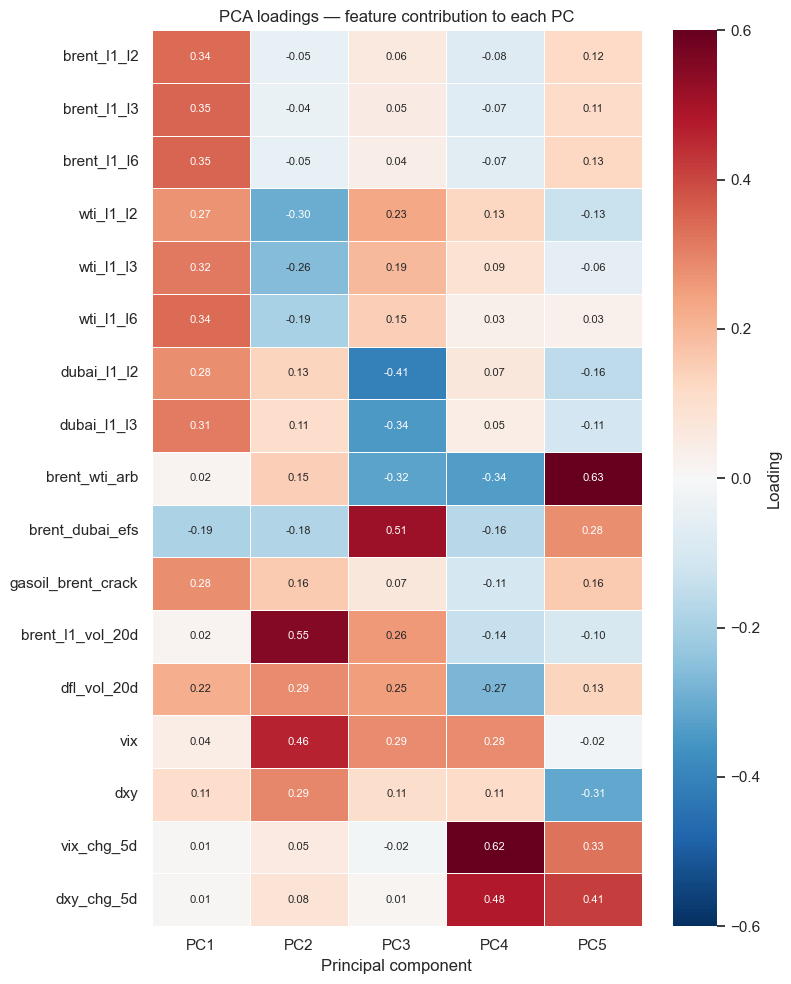

In [14]:
# Cell 6 — Fit PCA on the standardized features

pca = PCA(random_state=42)
pca.fit(X_scaled)   

# Explained variance per component
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"PCA fitted on {X_scaled.shape[1]} features\n")
print(f"{'PC':>4} {'explained':>10} {'cumulative':>11}")
print("-" * 28)
for i, (e, c) in enumerate(zip(explained, cumulative), start=1):
    print(f"PC{i:<2} {e*100:>9.1f}% {c*100:>10.1f}%")


# Cell 6b — PCA loadings: which features drive each component

n_show = 5  # interpret the first 5 components

# Loadings matrix: rows = features, cols = PCs
loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    index=X_scaled.columns,
    columns=[f"PC{i}" for i in range(1, n_show + 1)],
)

# Top features per PC (by absolute loading), with sign
print("=== Top features driving each component ===")
for i, pc in enumerate(loadings.columns):
    top = loadings[pc].abs().sort_values(ascending=False).head(6)
    print(f"\n{pc}  ({explained[i]*100:.1f}% of variance):")
    for feat in top.index:
        val = loadings.loc[feat, pc]
        sign = "+" if val > 0 else "-"
        print(f"   {sign} {abs(val):.2f}  {feat}")


# Cell 6c — Loadings heatmap

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap( 
    loadings,
    cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cbar_kws={"label": "Loading"},
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("PCA loadings — feature contribution to each PC", fontsize=12)
ax.set_xlabel("Principal component")
plt.tight_layout()
plt.show()


## Dimensionality reduction with PCA

### Purpose

The 17 regime features are economically meaningful but **partially redundant**
(e.g. the Brent calendar spreads at different horizons co-move, as seen in the
correlation matrix in notebook 01). Feeding all 17 correlated features directly
into K-means would let correlated groups implicitly **over-weight** the same
underlying signal, and would make the clustering harder to interpret.

PCA addresses this by projecting the 17 features onto a smaller set of
**orthogonal (uncorrelated) components**, ordered by the amount of variance they
capture. We then cluster on these components instead of the raw features.

### Standardization (prerequisite)

PCA is variance-based, so features must be on a comparable scale first. We applied
`StandardScaler` (z-score: each feature centered to mean 0, unit variance).
Without it, large-magnitude features (VIX ~10-80, stock anomalies ~±100,000) would
dominate the principal components purely because of their numerical range, not
because they carry more regime information. After scaling, PCA operates on the
**correlation structure** of the features, not their raw magnitudes.

*Note on robustness:* StandardScaler uses the mean and standard deviation, which
are sensitive to the extreme outliers (COVID, Russia, April 2026). RobustScaler
(median / IQR) would be a more outlier-robust alternative. We keep StandardScaler
here as it is the conventional choice for PCA (equivalent to PCA on the correlation
matrix) and because we *want* the stress days to stand out for regime separation.

### Results

| Component | Explained variance | Cumulative |
|---|---|---|
| PC1 | 43.0% | 43.0% |
| PC2 | 12.9% | 55.9% |
| PC3 | 9.8% | 65.7% |
| PC4 | 8.6% | 74.3% | 
| PC5 | 7.2% | 81.4% |
| PC6 | 5.3% | 86.7% |
| PC7+ | < 5% each | → 100% |

**PC1 alone captures 43%** of the total variance — a single dominant factor. In
financial data this typically reflects a market-wide "risk / stress" dimension
where volatilities, curve tightness and macro variables move together. We confirm
its economic meaning by inspecting the loadings (next step).

### Component selection: 5 components

Two independent criteria converge on the same answer:

1. **80% variance threshold**: the first 5 components retain 81.4% of the total
    variance — a standard cutoff that keeps the signal while discarding the noise
    in the trailing components (PC6 onward each add < 6%).

2. **Kaiser criterion (eigenvalue > 1)**: keep components explaining more than
    `1/17 = 5.88%` of the variance. PC1–PC5 all exceed this threshold (7.2%–43.0%);
    PC6 falls just below (5.3%). This yields exactly 5 components.

The agreement of both criteria on **5 components** makes the choice robust and easy
to defend. We retain 5 principal components (81.4% of variance) as the input to the
K-means clustering in notebook 03.

### Conclusion

We reduced 17 correlated, economically-motivated features to **5 orthogonal
components** capturing 81.4% of the variance. This:
- removes redundancy (correlated features no longer double-count),
- denoises the input (the trailing 12 components, mostly noise, are dropped),
- keeps the clustering tractable and interpretable.

The next step is to **interpret the loadings** of each component (which original
features drive PC1, PC2, …) to give the eventual regimes an economic meaning, and
then run K-means on these 5 components.


PCA construit ses combinaisons linéaires pour qu'elles capturent le maximum de variance (= le maximum de "dispersion" des données), en ordre décroissant :

- PC1 = la direction où les jours sont le plus étalés (variance max)
- PC2 = la direction orthogonale à PC1 où il reste le plus de variance
- PC3 = orthogonale aux deux premières, max variance restante
- etc.

Le % d'un PC = la fraction de la variance totale des données que ce PC capture. C'est sa "part d'information".




PC1 (43%) — Structure de courbe globale / backwardation

+0.35 brent_l1_l3   +0.35 brent_l1_l6   +0.34 brent_l1_l2
+0.34 wti_l1_l6     +0.32 wti_l1_l3     +0.31 dubai_l1_l3

Tous les calendar spreads (Brent + WTI + Dubai) chargent ensemble, tous positifs, magnitudes quasi-identiques. C'est le facteur de tightness physique global :
- PC1 élevé → toutes les courbes crude en backwardation simultanément → marché physique tendu partout
- PC1 bas → toutes en contango → marché sur-approvisionné

C'est logique que ce soit le facteur dominant (43%) : la forme de courbe est LE signal de régime n°1 en pétrole. Quand le marché physique se tend, ça se voit sur les
3 benchmarks en même temps.

→ Nom : "Global curve / physical tightness factor"

PC2 (12.9%) — Volatilité / risk-off

+0.55 brent_l1_vol_20d   +0.46 vix   +0.29 dxy   +0.29 dfl_vol_20d
-0.30 wti_l1_l2          -0.26 wti_l1_l3

Les vols + VIX + DXY positifs, les spreads WTI prompt négatifs. Signature classique du stress risk-off :
- PC2 élevé → vol réalisée haute + VIX haut + dollar fort + courbe WTI qui s'aplatit
- C'est le pattern "panique" : la vol explose, le dollar se renforce (fuite vers la sécurité), le prompt faiblit

→ Nom : "Volatility / risk-off stress factor"

PC3 (9.8%) — Arbitrage géographique East-West

+0.51 brent_dubai_efs   -0.41 dubai_l1_l2   -0.34 dubai_l1_l3
-0.32 brent_wti_arb     +0.29 vix           +0.26 brent_l1_vol_20d

Contraste le Brent-Dubai EFS (positif) contre la courbe Dubai et le Brent-WTI arb (négatifs). C'est l'axe Atlantique vs Asie :
- PC3 élevé → Brent riche vs Dubai (EFS large), courbe Dubai qui s'aplatit
- Capture la dislocation entre le bassin Atlantique et l'Asie

→ Nom : "East-West geographic arbitrage factor"

PC4 (8.6%) — Momentum macro / choc

+0.62 vix_chg_5d   +0.48 dxy_chg_5d   +0.28 vix
-0.34 brent_wti_arb  -0.27 dfl_vol_20d  -0.16 brent_dubai_efs

Ce sont les changements (vix_chg_5d, dxy_chg_5d) qui dominent, pas les niveaux. C'est le facteur de vitesse du choc macro :
- PC4 élevé → VIX et DXY accélèrent rapidement → un choc frais est en train de se dérouler
- Différent de PC2 (qui capte le niveau de stress) : PC4 capte la dynamique (ça bouge vite maintenant)

→ Nom : "Macro momentum / shock factor"

PC5 (7.2%) — Arbitrage trans-Atlantique Brent-WTI

+0.63 brent_wti_arb   +0.41 dxy_chg_5d   +0.33 vix_chg_5d
-0.31 dxy             +0.28 brent_dubai_efs  -0.16 dubai_l1_l2

Le Brent-WTI arb domine largement. C'est l'axe spécifiquement Atlantique :
- PC5 élevé → Brent riche vs WTI (arb large), dollar faible
- Capture la dynamique du spread trans-Atlantique, relativement indépendante du reste

→ Nom : "Trans-Atlantic (Brent-WTI) arbitrage factor"

Pourquoi c'est un super résultat

Tes 5 composantes mappent chacune sur une dimension distincte et nommable du marché crude :

┌─────┬──────────┬──────────────────────────────────────────────────────────┐
│ PC  │ Variance │                   Dimension économique                   │
├─────┼──────────┼──────────────────────────────────────────────────────────┤
│ PC1 │ 43%      │ Tightness physique globale (backwardation des 3 courbes) │
├─────┼──────────┼──────────────────────────────────────────────────────────┤
│ PC2 │ 13%      │ Stress / volatilité / risk-off                           │
├─────┼──────────┼──────────────────────────────────────────────────────────┤
│ PC3 │ 10%      │ Arbitrage géographique East-West (Brent-Dubai)           │
├─────┼──────────┼──────────────────────────────────────────────────────────┤
│ PC4 │ 9%       │ Momentum / vitesse du choc macro                         │
├─────┼──────────┼──────────────────────────────────────────────────────────┤
│ PC5 │ 7%       │ Arbitrage trans-Atlantique (Brent-WTI)                   │
└─────┴──────────┴──────────────────────────────────────────────────────────┘

C'est rare et précieux : souvent les PCs sont des mélanges illisibles. Ici tu as une séparation nette — tu pourras dire en interview "mes régimes se définissent sur 
5 axes interprétables : tightness, stress, géographie East-West, momentum macro, et arb Atlantique". C'est exactement ce qu'un quant veut entendre.

Ce que ça implique pour le K-means

Quand on clusterisera sur ces 5 PCs, un régime sera défini par sa position sur ces 5 axes. Par exemple :
- Régime "stress extrême" = PC1 très haut (backwardation) + PC2 très haut (vol) → ce sera probablement les jours COVID/Russie/2026
- Régime "calme" = tous les PCs proches de 0
- Régime "dislocation géographique" = PC3 élevé sans forcément PC2


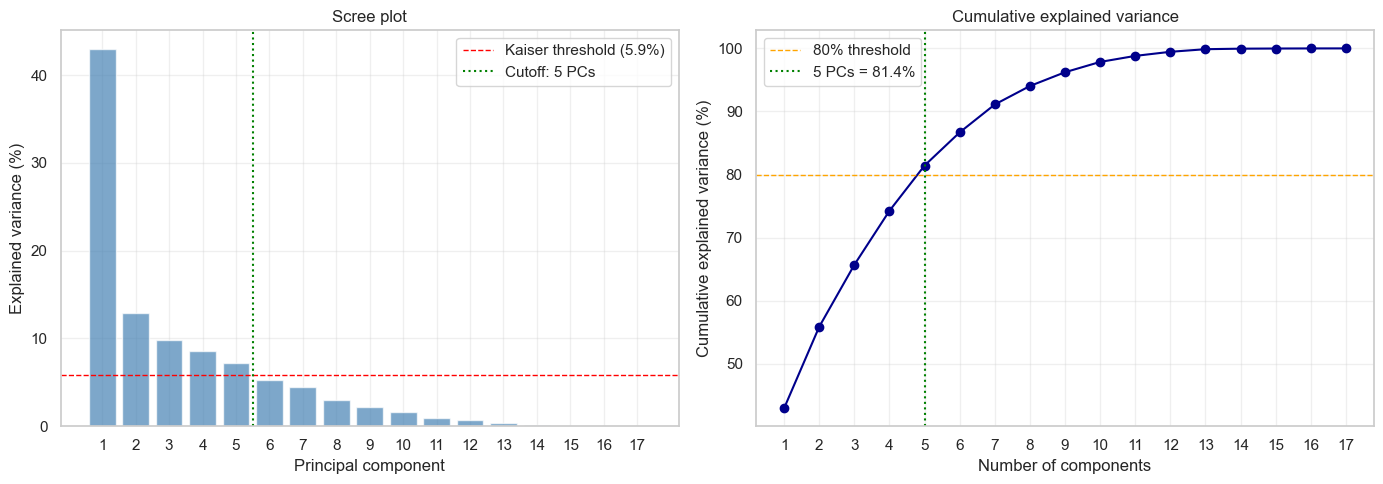

Selected: 5 components -> 81.4% variance retained


In [15]:
# Cell 7 — Scree plot and component selection

n_features = X_scaled.shape[1]
kaiser_threshold = 1 / n_features  # eigenvalue > 1 ⟺ explained ratio > 1/n_features
n_components_chosen = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot (variance per component)
ax = axes[0]
pcs = np.arange(1, len(explained) + 1)
ax.bar(pcs, explained * 100, color="steelblue", alpha=0.7)
ax.axhline(kaiser_threshold * 100, color="red", linestyle="--", lw=1,
            label=f"Kaiser threshold ({kaiser_threshold*100:.1f}%)")
ax.axvline(n_components_chosen + 0.5, color="green", linestyle=":", lw=1.5,
            label=f"Cutoff: {n_components_chosen} PCs")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree plot")
ax.set_xticks(pcs)
ax.legend()
ax.grid(alpha=0.3)

# Right: cumulative variance  
ax = axes[1]
ax.plot(pcs, cumulative * 100, marker="o", color="darkblue", lw=1.5)
ax.axhline(80, color="orange", linestyle="--", lw=1, label="80% threshold")
ax.axvline(n_components_chosen, color="green", linestyle=":", lw=1.5,
            label=f"{n_components_chosen} PCs = {cumulative[n_components_chosen-1]*100:.1f}%")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Cumulative explained variance")
ax.set_xticks(pcs)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Selected: {n_components_chosen} components -> {cumulative[n_components_chosen-1]*100:.1f}% variance retained")

In [16]:
# Cell 8 — Project onto 5 components and save for K-means

from pathlib import Path

n_components = 5
pca_final = PCA(n_components=n_components, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

# Wrap into a DataFrame: dates × 5 PC scores
pca_scores = pd.DataFrame(
    X_pca,
    index=X_scaled.index,
    columns=[f"PC{i}" for i in range(1, n_components + 1)],
)

print(f"PCA scores shape : {pca_scores.shape}")
print(f"Date range       : {pca_scores.index.min().date()} -> {pca_scores.index.max().date()}")
print(f"Variance retained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")
print()
print(pca_scores.head())

# Save for notebook 03 (K-means)
out_dir = Path("../data/processed")
out_dir.mkdir(exist_ok=True)
pca_scores.to_pickle(out_dir / "pca_scores.pkl")
pca_scores.to_csv(out_dir / "pca_scores.csv")
print(f"\nSaved → {out_dir}/pca_scores.pkl  +  .csv")

PCA scores shape : (3035, 5)
Date range       : 2014-01-30 -> 2026-05-06
Variance retained: 81.4%

             PC1    PC2    PC3    PC4   PC5
date                                       
2014-01-30 0.170 -1.728 -0.338 -0.227 2.991
2014-01-31 0.236 -1.795 -0.100 -0.558 2.481
2014-02-03 0.304 -1.405 -0.241  0.111 2.929
2014-02-04 0.265 -1.650 -0.211 -0.067 2.540
2014-02-05 0.127 -1.540 -0.228 -0.204 2.550

Saved → ../data/processed/pca_scores.pkl  +  .csv
